In [1]:
import pandas as pd
data = pd.read_csv("../data/data_preprossing.csv")
data.shape

(652, 13)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

X = data.drop(["List Price","IPO_Name","Date","Listing Gain","CMP(BSE)","CMP(NSE)","Current Gains"], axis=1)
y = data["List Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.20 , random_state = 1)
model = XGBRegressor(random_state = 1)

params = {    
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2],
}

random_xgb_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1
)


random_xgb_search.fit(X_train, y_train)
print(random_xgb_search.best_params_)
best_xgb_model = random_xgb_search.best_estimator_

{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.9}


In [3]:
y_xgb_pred = best_xgb_model.predict(X_test)
print(y_xgb_pred)

[  26.758001   64.187744  103.93337   111.30833   706.2271    155.35275
  257.48257   613.7929    768.6466    255.47263   341.14392   389.72665
   68.12777   136.54077   868.03436   728.24316    96.973915  571.82074
   76.85016   170.42969   308.72214    72.10505   570.42847  1134.2625
  167.5526    310.65665   486.0585     64.90327   349.11557   257.4449
  132.8024    158.76456   366.375     264.77106   306.05798  1262.1077
  122.05385   279.53082   105.72508   552.9751    499.93597    96.47145
  468.71832   485.8998    843.764     411.73413    20.124939  712.1468
   90.141335  209.42825   229.06567   157.2896   1880.4177    196.09991
  183.89467   334.8112    122.58283    96.17429   582.7475    214.64627
  421.40927   191.806     181.32349  1361.393     302.7321     77.080864
  159.1992     56.194725  168.86534   585.32336    28.228712  468.35843
  292.4235    965.25195   959.0642    291.6235    956.6102     89.32653
  490.48126   406.90076   203.95378    55.20992    75.236115  268.0

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_xgb_pred)
mse = mean_squared_error(y_test, y_xgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_xgb_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 58.97523248104649
MSE : 9931.252085487304
RMSE: 99.65566760343991
R2  : 0.944758603071134


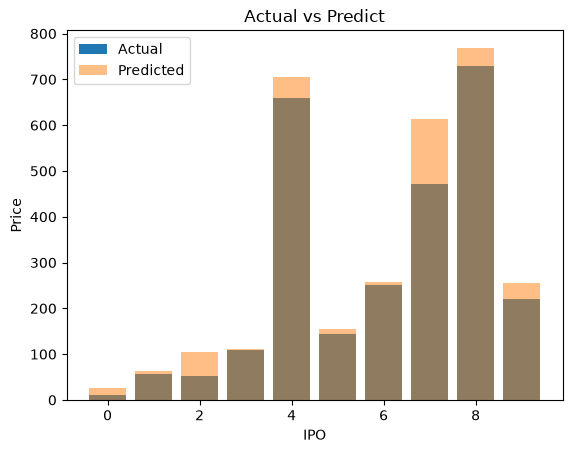

In [5]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(10,6))

plt.bar(range(10), y_test[:10], label="Actual")
plt.bar(range(10), y_xgb_pred[:10], alpha=0.5, label="Predicted")

plt.xlabel("IPO")
plt.ylabel("Price")
plt.title("Actual vs Predict")
plt.legend()

plt.show()

In [6]:
import joblib
joblib.dump(best_xgb_model , "Xgboost_Hyperparameter_Tuning.pkl")

['Xgboost_Hyperparameter_Tuning.pkl']